# Lagrangian EOM: Spherical Shell with Internal Pendulum on an Inclined Plane

Consider a spherical shell of mass $m_h$ and radius $R$. A heavy particle $D$ of mass $m_p$ is attached to the center of the shell with a pendulum of length $l$. The sphere is located on an inclined plane which makes an angle $\beta$ with the horizontal.

**Degrees of Freedom (8 total):**
- Sphere center: $x, y, z$ (translational, in incline frame)
- Sphere orientation: $\psi, \theta, \phi$ (3-2-1 Euler angles)
- Pendulum: $\alpha_p, \beta_p$ (spherical coordinates in body frame)


## Plotting

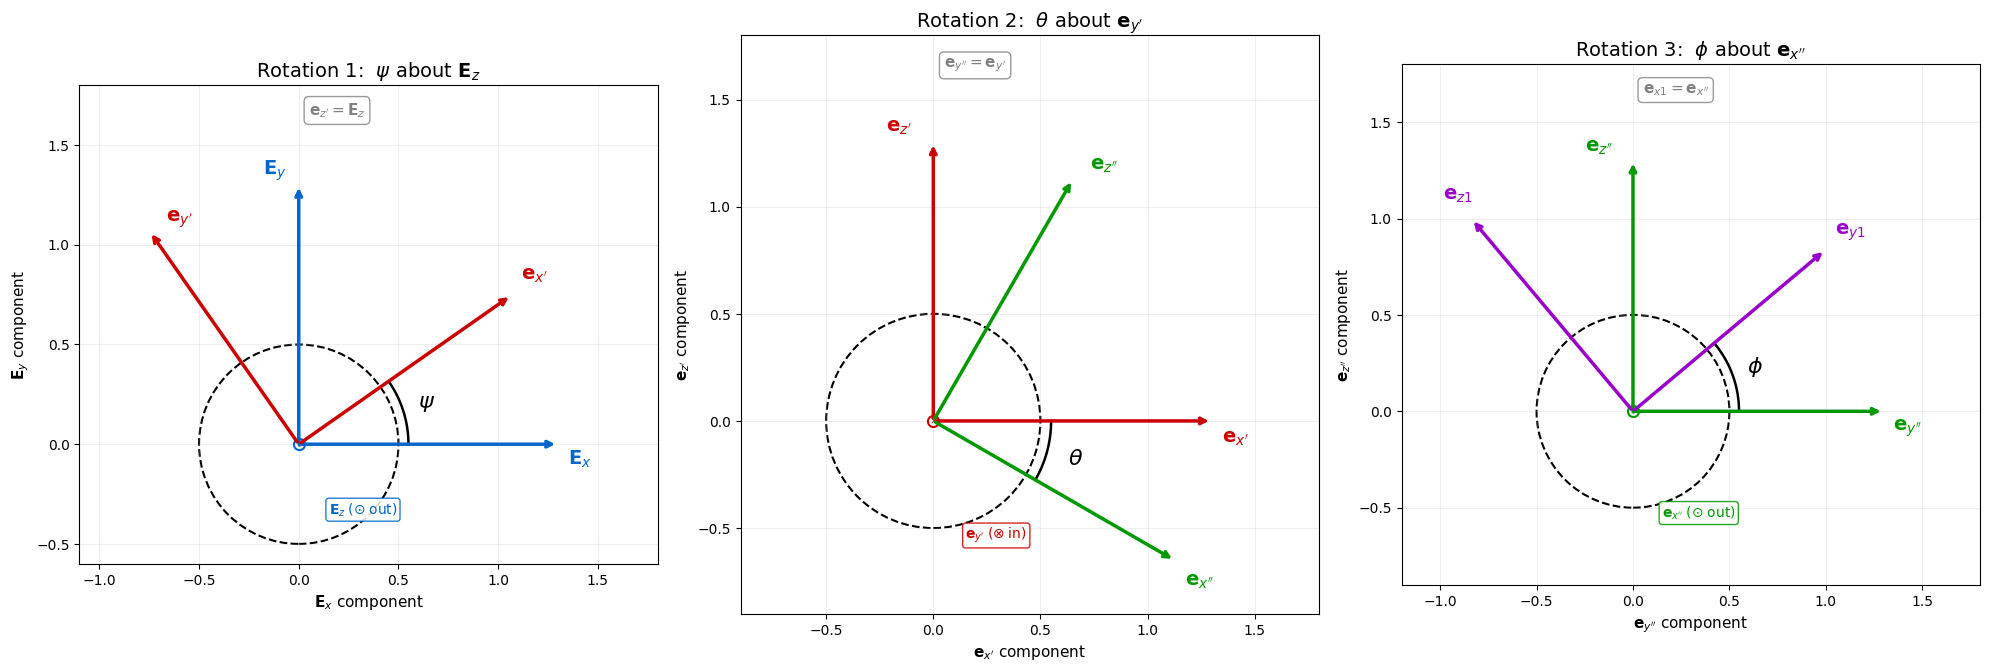

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
arr = 1.3   # arrow length
arc_r = 0.55  # angle arc radius
circ_r = 0.5  # circle radius at origin

# Draw a circle at the origin of each subplot
for ax in axes:
    circle = plt.Circle((0, 0), circ_r, fill=False, color='black', lw=1.5, ls='--', zorder=0)
    ax.add_patch(circle)

# ============================================================
# PLOT 1: Rotation psi about E_z  (view in E_x - E_y plane)
# ============================================================
ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.8)
ax.set_ylim(-0.6, 1.8)
ax.set_title(r'Rotation 1:  $\psi$ about $\mathbf{E}_z$', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlabel(r'$\mathbf{E}_x$ component', fontsize=11)
ax.set_ylabel(r'$\mathbf{E}_y$ component', fontsize=11)

ps = np.radians(35)

# Incline basis (before rotation)
ax.annotate('', xy=(arr, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#0066cc', lw=2.5))
ax.annotate('', xy=(0, arr), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#0066cc', lw=2.5))
ax.text(arr + 0.05, -0.1, r'$\mathbf{E}_x$', fontsize=14, color='#0066cc', fontweight='bold')
ax.text(-0.18, arr + 0.05, r'$\mathbf{E}_y$', fontsize=14, color='#0066cc', fontweight='bold')

# E_z out of page (dot in circle at origin + label inside axes)
ax.plot(0, 0, 'o', color='#0066cc', ms=8, mfc='none', mew=1.5)
ax.plot(0, 0, '.', color='#0066cc', ms=4)
ax.text(0.15, -0.35, r'$\mathbf{E}_z\;(\odot\;\mathrm{out})$', fontsize=10, color='#0066cc',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#0066cc', alpha=0.85))

# Rotated basis
ex_p = np.array([np.cos(ps), np.sin(ps)])
ey_p = np.array([-np.sin(ps), np.cos(ps)])

ax.annotate('', xy=arr * ex_p, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2.5))
ax.annotate('', xy=arr * ey_p, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2.5))
ax.text(*(arr * ex_p + np.array([0.05, 0.08])),
        r"$\mathbf{e}_{x'}$", fontsize=14, color='#cc0000', fontweight='bold')
ax.text(*(arr * ey_p + np.array([0.08, 0.05])),
        r"$\mathbf{e}_{y'}$", fontsize=14, color='#cc0000', fontweight='bold')

# Angle arc
angles = np.linspace(0, ps, 40)
ax.plot(arc_r * np.cos(angles), arc_r * np.sin(angles), '-', color='black', lw=1.8)
mid = ps / 2
ax.text(arc_r * 1.22 * np.cos(mid), arc_r * 1.22 * np.sin(mid),
        r'$\psi$', fontsize=16, fontweight='bold', ha='center', va='center')

ax.text(0.05, 1.65, r"$\mathbf{e}_{z'} = \mathbf{E}_z$", fontsize=11, color='gray',
        fontstyle='italic', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# ============================================================
# PLOT 2: Rotation theta about e_y'  (view in e_x' - e_z' plane)
# ============================================================
ax = axes[1]
ax.set_aspect('equal')
ax.set_xlim(-0.9, 1.8)
ax.set_ylim(-0.9, 1.8)
ax.set_title(r"Rotation 2:  $\theta$ about $\mathbf{e}_{y'}$", fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlabel(r"$\mathbf{e}_{x'}$ component", fontsize=11)
ax.set_ylabel(r"$\mathbf{e}_{z'}$ component", fontsize=11)

th = np.radians(30)

# Before rotation: e_x', e_z'
ax.annotate('', xy=(arr, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2.5))
ax.annotate('', xy=(0, arr), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2.5))
ax.text(arr + 0.05, -0.1, r"$\mathbf{e}_{x'}$", fontsize=14, color='#cc0000', fontweight='bold')
ax.text(-0.22, arr + 0.05, r"$\mathbf{e}_{z'}$", fontsize=14, color='#cc0000', fontweight='bold')

# e_y' into page (cross in circle at origin + label inside axes)
ax.plot(0, 0, 'o', color='#cc0000', ms=8, mfc='none', mew=1.5)
ax.text(0.0, 0.0, r'$\times$', fontsize=7, color='#cc0000', ha='center', va='center')
ax.text(0.15, -0.55, r"$\mathbf{e}_{y'}\;(\otimes\;\mathrm{in})$", fontsize=10, color='#cc0000',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#cc0000', alpha=0.85))

# After rotation: e_x'', e_z''
ex_pp = np.array([np.cos(th), -np.sin(th)])
ez_pp = np.array([np.sin(th),  np.cos(th)])

ax.annotate('', xy=arr * ex_pp, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#009900', lw=2.5))
ax.annotate('', xy=arr * ez_pp, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#009900', lw=2.5))
ax.text(*(arr * ex_pp + np.array([0.05, -0.12])),
        r"$\mathbf{e}_{x''}$", fontsize=14, color='#009900', fontweight='bold')
ax.text(*(arr * ez_pp + np.array([0.08, 0.05])),
        r"$\mathbf{e}_{z''}$", fontsize=14, color='#009900', fontweight='bold')

# Angle arc theta (from e_x' to e_x'')
angles_th = np.linspace(0, -th, 40)
ax.plot(arc_r * np.cos(angles_th), arc_r * np.sin(angles_th), '-', color='black', lw=1.8)
mid_th = -th / 2
ax.text(arc_r * 1.25 * np.cos(mid_th), arc_r * 1.25 * np.sin(mid_th),
        r'$\theta$', fontsize=16, fontweight='bold', ha='center', va='center')

ax.text(0.05, 1.65, r"$\mathbf{e}_{y''} = \mathbf{e}_{y'}$", fontsize=11, color='gray',
        fontstyle='italic', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# ============================================================
# PLOT 3: Rotation phi about e_x''  (view in e_y'' - e_z'' plane)
# ============================================================
ax = axes[2]
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.8)
ax.set_ylim(-0.9, 1.8)
ax.set_title(r"Rotation 3:  $\phi$ about $\mathbf{e}_{x''}$", fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlabel(r"$\mathbf{e}_{y''}$ component", fontsize=11)
ax.set_ylabel(r"$\mathbf{e}_{z''}$ component", fontsize=11)

ph = np.radians(40)

# Before rotation: e_y'', e_z''
ax.annotate('', xy=(arr, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#009900', lw=2.5))
ax.annotate('', xy=(0, arr), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#009900', lw=2.5))
ax.text(arr + 0.05, -0.1, r"$\mathbf{e}_{y''}$", fontsize=14, color='#009900', fontweight='bold')
ax.text(-0.25, arr + 0.05, r"$\mathbf{e}_{z''}$", fontsize=14, color='#009900', fontweight='bold')

# e_x'' out of page (dot in circle at origin + label inside axes)
ax.plot(0, 0, 'o', color='#009900', ms=8, mfc='none', mew=1.5)
ax.plot(0, 0, '.', color='#009900', ms=4)
ax.text(0.15, -0.55, r"$\mathbf{e}_{x''}\;(\odot\;\mathrm{out})$", fontsize=10, color='#009900',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#009900', alpha=0.85))

# After rotation: e_y1, e_z1
ey1_d = np.array([np.cos(ph), np.sin(ph)])
ez1_d = np.array([-np.sin(ph), np.cos(ph)])

ax.annotate('', xy=arr * ey1_d, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9900cc', lw=2.5))
ax.annotate('', xy=arr * ez1_d, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9900cc', lw=2.5))
ax.text(*(arr * ey1_d + np.array([0.05, 0.08])),
        r'$\mathbf{e}_{y1}$', fontsize=14, color='#9900cc', fontweight='bold')
ax.text(*(arr * ez1_d + np.array([-0.15, 0.1])),
        r'$\mathbf{e}_{z1}$', fontsize=14, color='#9900cc', fontweight='bold')

# Angle arc phi (from e_y'' to e_y1)
angles_ph = np.linspace(0, ph, 40)
ax.plot(arc_r * np.cos(angles_ph), arc_r * np.sin(angles_ph), '-', color='black', lw=1.8)
mid_ph = ph / 2
ax.text(arc_r * 1.22 * np.cos(mid_ph), arc_r * 1.22 * np.sin(mid_ph),
        r'$\phi$', fontsize=16, fontweight='bold', ha='center', va='center')

ax.text(0.05, 1.65, r"$\mathbf{e}_{x1} = \mathbf{e}_{x''}$", fontsize=11, color='gray',
        fontstyle='italic', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

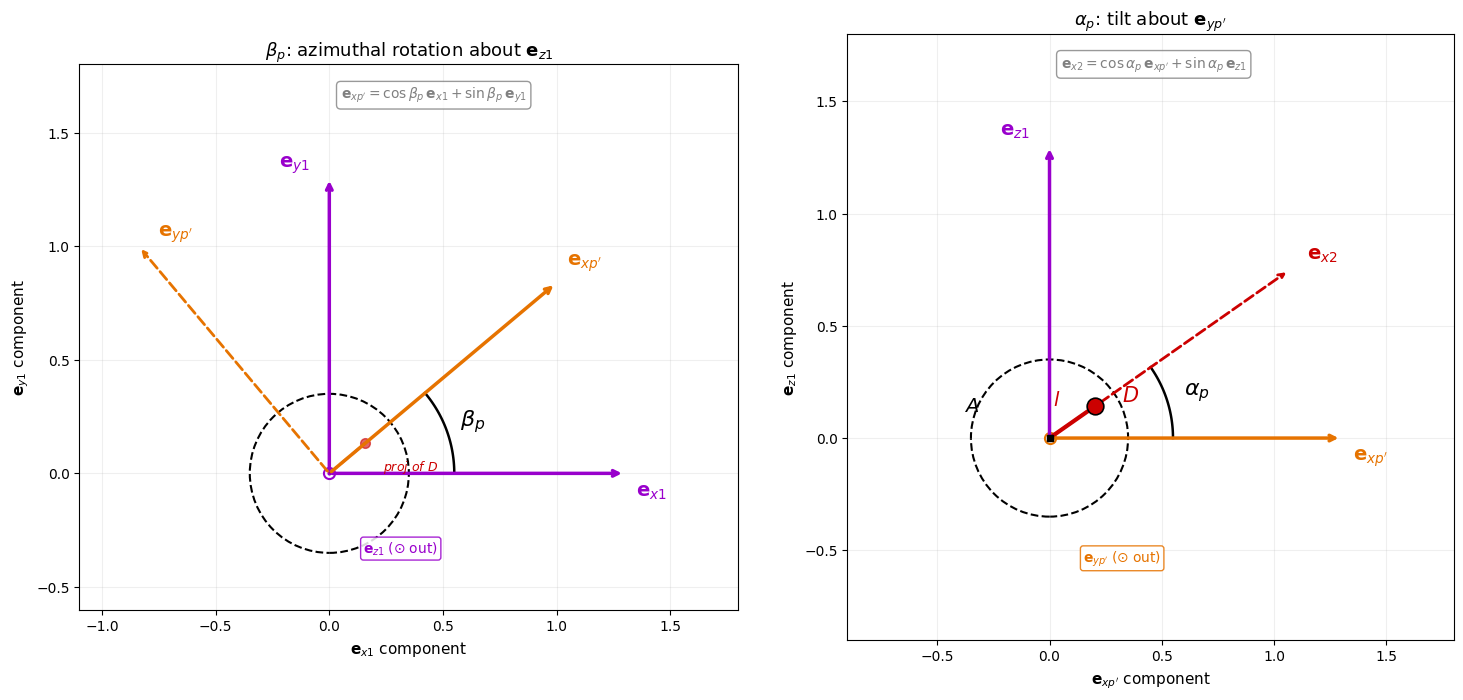

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
arr = 1.3    # basis arrow length
arc_r = 0.55 # angle arc radius
circ_r = 0.35
pend_len = 0.25  # pendulum rod length in plot

# Draw a circle at the origin of each subplot
for ax in axes:
    circle = plt.Circle((0, 0), circ_r, fill=False, color='black', lw=1.5, ls='--', zorder=0)
    ax.add_patch(circle)

bp = np.radians(40)  # beta_p
ap = np.radians(35)  # alpha_p

# ============================================================
# PLOT 1: beta_p about e_z1  (top-down view: e_x1 - e_y1 plane)
#   Shows the azimuthal rotation selecting the meridional plane
# ============================================================
ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.8)
ax.set_ylim(-0.6, 1.8)
ax.set_title(r"$\beta_p$: azimuthal rotation about $\mathbf{e}_{z1}$", fontsize=13)
ax.grid(True, alpha=0.2)
ax.set_xlabel(r'$\mathbf{e}_{x1}$ component', fontsize=11)
ax.set_ylabel(r'$\mathbf{e}_{y1}$ component', fontsize=11)

# Body basis e_x1, e_y1 (purple)
ax.annotate('', xy=(arr, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9900cc', lw=2.5))
ax.annotate('', xy=(0, arr), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9900cc', lw=2.5))
ax.text(arr + 0.05, -0.1, r'$\mathbf{e}_{x1}$', fontsize=14, color='#9900cc', fontweight='bold')
ax.text(-0.22, arr + 0.05, r'$\mathbf{e}_{y1}$', fontsize=14, color='#9900cc', fontweight='bold')

# e_z1 out of page (rotation axis)
ax.plot(0, 0, 'o', color='#9900cc', ms=8, mfc='none', mew=1.5)
ax.plot(0, 0, '.', color='#9900cc', ms=4)
ax.text(0.15, -0.35, r"$\mathbf{e}_{z1}\;(\odot\;\mathrm{out})$", fontsize=10, color='#9900cc',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#9900cc', alpha=0.85))

# e_xp' direction (orange): cos(bp) e_x1 + sin(bp) e_y1
e_xp = np.array([np.cos(bp), np.sin(bp)])
e_yp = np.array([-np.sin(bp), np.cos(bp)])

ax.annotate('', xy=arr * e_xp, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#e67300', lw=2.5))
ax.text(*(arr * e_xp + np.array([0.05, 0.08])),
        r"$\mathbf{e}_{xp'}$", fontsize=14, color='#e67300', fontweight='bold')

# e_yp' direction (orange dashed)
ax.annotate('', xy=arr * e_yp, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#e67300', lw=2, ls='dashed'))
ax.text(*(arr * e_yp + np.array([0.08, 0.05])),
        r"$\mathbf{e}_{yp'}$", fontsize=14, color='#e67300', fontweight='bold')

# Pendulum projection in this plane (dashed, along e_xp' scaled by cos(ap))
proj_len = pend_len * np.cos(ap)
ax.plot([0, proj_len * e_xp[0]], [0, proj_len * e_xp[1]],
        '--', color='#cc0000', lw=2, alpha=0.6)
ax.plot(proj_len * e_xp[0], proj_len * e_xp[1], 'o', color='#cc0000', ms=7, alpha=0.6)
ax.text(proj_len * e_xp[0] + 0.08, proj_len * e_xp[1] - 0.12,
        r'proj of $D$', fontsize=9, color='#cc0000', fontstyle='italic')

# Angle arc beta_p
angles_bp = np.linspace(0, bp, 40)
ax.plot(arc_r * np.cos(angles_bp), arc_r * np.sin(angles_bp), '-', color='black', lw=1.8)
mid_bp = bp / 2
ax.text(arc_r * 1.22 * np.cos(mid_bp), arc_r * 1.22 * np.sin(mid_bp),
        r'$\beta_p$', fontsize=16, fontweight='bold', ha='center', va='center')

# Note
ax.text(0.05, 1.65,
        r"$\mathbf{e}_{xp'} = \cos\beta_p\,\mathbf{e}_{x1} + \sin\beta_p\,\mathbf{e}_{y1}$",
        fontsize=10, color='gray', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# ============================================================
# PLOT 2: alpha_p about e_yp'  (side view: e_xp' - e_z1 plane)
#   Shows the tilt from e_xp' toward e_zp', producing e_x2
#   Rotation axis is e_yp' (out of page)
# ============================================================
ax = axes[1]
ax.set_aspect('equal')
ax.set_xlim(-0.9, 1.8)
ax.set_ylim(-0.9, 1.8)
ax.set_title(r"$\alpha_p$: tilt about $\mathbf{e}_{yp'}$", fontsize=13)
ax.grid(True, alpha=0.2)
ax.set_xlabel(r"$\mathbf{e}_{xp'}$ component", fontsize=11)
ax.set_ylabel(r"$\mathbf{e}_{z1}$ component", fontsize=11)

# e_xp' (horizontal, orange) and e_z1 (vertical, purple)
ax.annotate('', xy=(arr, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#e67300', lw=2.5))
ax.annotate('', xy=(0, arr), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9900cc', lw=2.5))
ax.text(arr + 0.05, -0.1, r"$\mathbf{e}_{xp'}$", fontsize=14, color='#e67300', fontweight='bold')
ax.text(-0.22, arr + 0.05, r"$\mathbf{e}_{z1}$", fontsize=14, color='#9900cc', fontweight='bold')

# e_yp' out of page (rotation axis for alpha_p)
ax.plot(0, 0, 'o', color='#e67300', ms=8, mfc='none', mew=1.5)
ax.plot(0, 0, '.', color='#e67300', ms=4)
ax.text(0.15, -0.55, r"$\mathbf{e}_{yp'}\;(\odot\;\mathrm{out})$", fontsize=10, color='#e67300',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#e67300', alpha=0.85))

# e_x2 direction: cos(alpha_p) e_xp' + sin(alpha_p) e_zp'
# In (e_xp', e_z1) plot coords: (cos(ap), sin(ap))
e_x2_d = np.array([np.cos(ap), np.sin(ap)])

# Draw pendulum rod from A to D along e_x2
ax.plot([0, pend_len * e_x2_d[0]], [0, pend_len * e_x2_d[1]],
        '-', color='#cc0000', lw=3, solid_capstyle='round')
# Bob at end
ax.plot(pend_len * e_x2_d[0], pend_len * e_x2_d[1],
        'o', color='#cc0000', ms=12, mec='black', mew=1.2, zorder=5)
ax.text(pend_len * e_x2_d[0] + 0.12, pend_len * e_x2_d[1] + 0.02,
        r'$D$', fontsize=15, color='#cc0000', fontweight='bold')

# e_x2 arrow (along pendulum direction)
ax.annotate('', xy=arr * e_x2_d, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2, ls='dashed'))
ax.text(*(arr * e_x2_d + np.array([0.08, 0.05])),
        r"$\mathbf{e}_{x2}$", fontsize=14, color='#cc0000', fontweight='bold')

# Label the sphere center
ax.plot(0, 0, 's', color='black', ms=5, zorder=6)
ax.text(-0.38, 0.12, r'$A$', fontsize=14, fontweight='bold')

# Pendulum length label
mid_pend = 0.5 * pend_len * e_x2_d
perp = np.array([-e_x2_d[1], e_x2_d[0]])
ax.text(*(mid_pend + 0.12 * perp), r'$l$', fontsize=14, fontweight='bold',
        ha='center', va='center', color='#cc0000')

# Angle arc alpha_p (from e_xp' toward e_x2)
angles_ap = np.linspace(0, ap, 40)
ax.plot(arc_r * np.cos(angles_ap), arc_r * np.sin(angles_ap), '-', color='black', lw=1.8)
mid_ap = ap / 2
ax.text(arc_r * 1.25 * np.cos(mid_ap), arc_r * 1.25 * np.sin(mid_ap),
        r'$\alpha_p$', fontsize=16, fontweight='bold', ha='center', va='center')

# Note definition
ax.text(0.05, 1.65,
        r"$\mathbf{e}_{x2} = \cos\alpha_p\,\mathbf{e}_{xp'} + \sin\alpha_p\,\mathbf{e}_{z1}$",
        fontsize=10, color='gray', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

In [3]:
import sympy as sp
from sympy import symbols, cos, sin, Matrix, trigsimp, Function, diff, latex, Rational
from sympy import Symbol
from IPython.display import display, Math

# Time variable
t = Symbol('t')

# Generalized coordinates as functions of time
x = Function('x')(t)
y = Function('y')(t)
z = Function('z')(t)
theta = Function('theta')(t)
phi = Function('phi')(t)
psi = Function('psi')(t)
alpha_p = Function('alpha_p')(t)
beta_p = Function('beta_p')(t)

# System parameters
R_s, l, m_h, m_p, g_val = symbols('R l m_h m_p g', positive=True)
I_xx, I_yy, I_zz = symbols('I_{xx} I_{yy} I_{zz}', positive=True)
beta_inc = symbols('beta', positive=True)  # incline angle (constant)

print('All symbols defined.')

All symbols defined.


## Step 1: World-Fixed and Incline-Fixed Bases

In [4]:
# Rotation from world {a,b,c} to incline {E_x, E_y, E_z}
# A vector v in the incline frame is expressed in the world frame as:
#   v_world = R_incline * v_incline

R_incline = Matrix([
    [cos(beta_inc), -sin(beta_inc), 0],
    [sin(beta_inc),  cos(beta_inc), 0],
    [0,              0,             1]
])

display(Math(r'R_{\text{incline}} = ' + latex(R_incline)))
print('Transforms incline-frame coordinates to world-frame coordinates.')

<IPython.core.display.Math object>

Transforms incline-frame coordinates to world-frame coordinates.


## Step 2: Sphere Euler Angle Rotations (3-2-1: $\psi$-$\theta$-$\phi$)

The sphere's corotational frame $\{\mathbf{e}_{x1}, \mathbf{e}_{y1}, \mathbf{e}_{z1}\}$ is obtained from the incline frame through three successive rotations.

### Rotation 1: $\psi$ about $\mathbf{E}_z$



In [5]:
# Rotation 1: psi about E_z
R_z_psi = Matrix([
    [cos(psi), -sin(psi), 0],
    [sin(psi),  cos(psi), 0],
    [0,           0,          1]
])

display(Math(r'R_z(\psi) = ' + latex(R_z_psi)))

<IPython.core.display.Math object>

### Rotation 2: $\theta$ about $\mathbf{e}_{y'}$

In [6]:
# Rotation 2: theta about e_y'
# From the basis transformation:
#   e_x'' = cos(theta) e_x' - sin(theta) e_z'
#   e_y'' = e_y'
#   e_z'' = sin(theta) e_x' + cos(theta) e_z'
# The matrix that converts double-prime coords to prime coords:
#   v_prime = R_y(theta) * v_double_prime

R_y_theta = Matrix([
    [ cos(theta), 0, sin(theta)],
    [ 0,          1,  0        ],
    [-sin(theta), 0,  cos(theta)]
])

display(Math(r"R_{y'}(\theta) = " + latex(R_y_theta)))

<IPython.core.display.Math object>

### Rotation 3: $\phi$ about $\mathbf{e}_{x''}$

In [7]:
# Rotation 3: phi about e_x''
R_x_phi = Matrix([
    [1, 0,        0       ],
    [0, cos(phi), -sin(phi)],
    [0, sin(phi),  cos(phi)]
])

display(Math(r"R_{x''}(\phi) = " + latex(R_x_phi)))

<IPython.core.display.Math object>

### Total Rotation Matrix (incline $\to$ body)

A vector expressed in the body frame $\{\mathbf{e}_{x1}, \mathbf{e}_{y1}, \mathbf{e}_{z1}\}$ is converted to the incline frame $\{\mathbf{E}_x, \mathbf{E}_y, \mathbf{E}_z\}$ by:
$$
R = R_z(\psi) \cdot R_{y'}(\theta) \cdot R_{x''}(\phi)
$$

The columns of $R$ are the body basis vectors expressed in the incline frame.

In [8]:
# Total rotation matrix: body -> incline
# v_incline = R_total * v_body
R_total = R_z_psi * R_y_theta * R_x_phi
R_total_simplified = trigsimp(R_total)

display(Math(r"R = R_z(\psi) \cdot R_{y'}(\theta) \cdot R_{x''}(\phi) = " + latex(R_total_simplified)))

<IPython.core.display.Math object>

## Step 3: Body-Frame Basis Vectors

The body-frame basis vectors expressed in the incline frame are the columns of $R$:

In [9]:
# Body frame basis vectors (columns of R_total), expressed in incline-frame coordinates
e_x1 = R_total[:, 0]
e_y1 = R_total[:, 1]
e_z1 = R_total[:, 2]

display(Math(r'\mathbf{e}_{x1} = ' + latex(trigsimp(e_x1))))
display(Math(r'\mathbf{e}_{y1} = ' + latex(trigsimp(e_y1))))
display(Math(r'\mathbf{e}_{z1} = ' + latex(trigsimp(e_z1))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Step 4: Angular Velocity of the Sphere

In [10]:
# Time derivatives of Euler angles
psi_dot = diff(psi, t)
theta_dot = diff(theta, t)
phi_dot = diff(phi, t)

# Basis vectors needed for angular velocity construction (in incline frame)
E_z = Matrix([0, 0, 1])  # E_z in incline-frame coords
E_y = Matrix([0, 1, 0])
E_x = Matrix([1, 0, 0])

# e_y' = R_z(psi) * E_y (after first rotation)
e_y_prime = R_z_psi * E_y

# e_x1 = R_z(psi) * R_y(theta) * R_x(phi) * E_x = first column of R_total
# (already computed above, but here we use it directly from R_total)

# Angular velocity of sphere in incline frame
omega_h_incline = psi_dot * E_z + theta_dot * e_y_prime + phi_dot * e_x1
omega_h_incline = trigsimp(omega_h_incline)

display(Math(r'\boldsymbol{\omega}_h \text{ (incline frame)} = ' + latex(omega_h_incline)))

<IPython.core.display.Math object>

In [11]:
# Angular velocity in body frame: omega_body = R^T * omega_incline
omega_h_body = trigsimp(R_total.T * omega_h_incline)

display(Math(r'\boldsymbol{\omega}_h^{\text{body}} = R^T \boldsymbol{\omega}_h = ' + latex(omega_h_body)))

print()
print('Verify components match the expected form:')
print(f'  omega_1 = {trigsimp(omega_h_body[0])}')
print(f'  omega_2 = {trigsimp(omega_h_body[1])}')
print(f'  omega_3 = {trigsimp(omega_h_body[2])}')

<IPython.core.display.Math object>


Verify components match the expected form:
  omega_1 = -sin(theta(t))*Derivative(psi(t), t) + Derivative(phi(t), t)
  omega_2 = sin(phi(t))*cos(theta(t))*Derivative(psi(t), t) + cos(phi(t))*Derivative(theta(t), t)
  omega_3 = -sin(phi(t))*Derivative(theta(t), t) + cos(phi(t))*cos(theta(t))*Derivative(psi(t), t)


## Step 5: Pendulum Direction and Angular Velocity

In [12]:
# Pendulum direction e_x2 in body-frame components
e_x2_body = Matrix([
    cos(alpha_p) * cos(beta_p),
    cos(alpha_p) * sin(beta_p),
    sin(alpha_p)
])

display(Math(r'\mathbf{e}_{x2}^{\text{body}} = ' + latex(e_x2_body)))

# Convert to incline frame
e_x2_incline = R_total * e_x2_body
e_x2_incline_simplified = trigsimp(e_x2_incline)

display(Math(r"\mathbf{e}_{x2}^{\text{incline}} = R \cdot \mathbf{e}_{x2}^{\text{body}} = " + latex(e_x2_incline_simplified)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
# Time derivatives of pendulum angles
alpha_p_dot = diff(alpha_p, t)
beta_p_dot = diff(beta_p, t)

# Relative angular velocity of pendulum w.r.t. sphere, in body-frame components:
# omega_rel = beta_p_dot * e_z1 + alpha_p_dot * e_yp'
#           = beta_p_dot * e_z1 + alpha_p_dot * (-sin(beta_p) e_x1 + cos(beta_p) e_y1)
omega_rel_body = Matrix([
    -alpha_p_dot * sin(beta_p),
     alpha_p_dot * cos(beta_p),
     beta_p_dot
])

display(Math(r'\boldsymbol{\omega}_{\text{rel}}^{\text{body}} = ' + latex(omega_rel_body)))

# Total pendulum angular velocity in body frame
omega_p_body = omega_h_body + omega_rel_body
omega_p_body = trigsimp(omega_p_body)

display(Math(r'\boldsymbol{\omega}_p^{\text{body}} = \boldsymbol{\omega}_h^{\text{body}} + \boldsymbol{\omega}_{\text{rel}}^{\text{body}} = ' + latex(omega_p_body)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Step 6: Position Vectors

In [14]:
# Position of sphere center A in incline frame
r_A = Matrix([x, y, z])

display(Math(r'\mathbf{r}_A = ' + latex(r_A)))

<IPython.core.display.Math object>

In [15]:
# Pendulum offset in body frame
r_DA_body = l * e_x2_body

display(Math(r'\mathbf{r}_{D/A}^{\text{body}} = l\,\mathbf{e}_{x2}^{\text{body}} = ' + latex(r_DA_body)))

<IPython.core.display.Math object>

In [16]:
# Pendulum offset in incline frame
r_DA_incline = R_total * r_DA_body
r_DA_incline_simplified = trigsimp(r_DA_incline)

display(Math(r'R \cdot \mathbf{r}_{D/A}^{\text{body}} = ' + latex(trigsimp(r_DA_incline_simplified))))

<IPython.core.display.Math object>

In [17]:
# Position of particle D in incline frame
r_D = r_A + r_DA_incline

display(Math(r'\mathbf{r}_D = \mathbf{r}_A + l\,R\,\mathbf{e}_{x2}^{\text{body}}'))

<IPython.core.display.Math object>

## Step 7: Velocities

In [18]:
# Velocity of sphere center
v_A = diff(r_A, t)

display(Math(r'\mathbf{v}_A = ' + latex(v_A)))

<IPython.core.display.Math object>

In [19]:
# Velocity of particle D
v_D = diff(r_D, t)

print(f'v_D has {len(v_D)} components (3D vector).')
print(f'Number of terms in v_D[0]: {len(sp.Add.make_args(sp.expand(v_D[0])))}')
print(f'Number of terms in v_D[1]: {len(sp.Add.make_args(sp.expand(v_D[1])))}')
print(f'Number of terms in v_D[2]: {len(sp.Add.make_args(sp.expand(v_D[2])))}')

v_D has 3 components (3D vector).
Number of terms in v_D[0]: 21
Number of terms in v_D[1]: 21
Number of terms in v_D[2]: 11
